In [1]:
import os
import requests
from dotenv import load_dotenv
import pandas as pd

In [2]:
load_dotenv()

api_key = os.getenv("FRED_API_KEY")

url = "https://api.stlouisfed.org/fred/series/observations"
cpi_yoy = 'CORESTICKM159SFRBATL'
params = {
    "series_id": cpi_yoy,
    "api_key": api_key,
    "file_type": "json"
}

response = requests.get(url, params=params)


In [3]:
response

<Response [200]>

In [4]:
# 200 means its good

In [15]:
# Extract observations and create the table
data = response.json()
data.keys()

dict_keys(['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations'])

In [16]:
data

{'realtime_start': '2026-09-11',
 'realtime_end': '2026-09-11',
 'observation_start': '1600-01-01',
 'observation_end': '9999-12-31',
 'units': 'lin',
 'output_type': 1,
 'file_type': 'json',
 'order_by': 'observation_date',
 'sort_order': 'asc',
 'count': 705,
 'offset': 0,
 'limit': 100000,
 'observations': [{'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1967-12-01',
   'value': '.'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-01-01',
   'value': '3.65186106'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-02-01',
   'value': '3.673819411'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-03-01',
   'value': '4.142163975'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-04-01',
   'value': '4.155828095'},
  {'realtime_start': '2026-09-11',
   'realtime_end': '2026-09-11',
   'date': '1968-05-01',
   

In [6]:
cpi_table = pd.DataFrame(data["observations"])

In [7]:
cpi_table.head()

,realtime_start,realtime_end,date,value
0,2026-09-11,2026-09-11,1967-12-01,.
1,2026-09-11,2026-09-11,1968-01-01,3.65186106
2,2026-09-11,2026-09-11,1968-02-01,3.673819411
3,2026-09-11,2026-09-11,1968-03-01,4.142163975
4,2026-09-11,2026-09-11,1968-04-01,4.155828095


In [8]:
cpi_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   realtime_start  705 non-null    str  
 1   realtime_end    705 non-null    str  
 2   date            705 non-null    str  
 3   value           705 non-null    str  
dtypes: str(4)
memory usage: 22.2 KB


In [9]:
# this shows that there are no null values, but I was able to see in my df that the first df['value'] was "."
# I will convert everything to the right dtype and try again. 

In [10]:
# Drop first row because value is "."
cpi_table = cpi_table.drop(cpi_table.index[0])

# Convert columns
cpi_table["realtime_start"] = pd.to_datetime(cpi_table["realtime_start"])
cpi_table["realtime_end"] = pd.to_datetime(cpi_table["realtime_end"])
cpi_table["date"] = pd.to_datetime(cpi_table["date"])
cpi_table["value"] = pd.to_numeric(cpi_table["value"])

In [11]:
cpi_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 1 to 704
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   realtime_start  704 non-null    datetime64[us]
 1   realtime_end    704 non-null    datetime64[us]
 2   date            704 non-null    datetime64[us]
 3   value           704 non-null    float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 22.1 KB


In [12]:
# ok looks like there is no null data

In [13]:
cpi_table.describe()

,realtime_start,realtime_end,date,value
count,704,704,704,704.000000
mean,2026-09-11 00:00:00,2026-09-11 00:00:00,1997-04-16 11:06:49.090909,4.293951
min,2026-09-11 00:00:00,2026-09-11 00:00:00,1968-01-01 00:00:00,0.663868
25%,2026-09-11 00:00:00,2026-09-11 00:00:00,1982-08-24 06:00:00,2.476294
50%,2026-09-11 00:00:00,2026-09-11 00:00:00,1997-04-16 00:00:00,3.350468
75%,2026-09-11 00:00:00,2026-09-11 00:00:00,2011-12-08 18:00:00,5.112544
max,2026-09-11 00:00:00,2026-09-11 00:00:00,2026-08-01 00:00:00,15.774167
std,NaN,NaN,NaN,2.646000


In [14]:
cpi_table

,realtime_start,realtime_end,date,value
1,2026-09-11,2026-09-11,1968-01-01,3.651861
2,2026-09-11,2026-09-11,1968-02-01,3.673819
3,2026-09-11,2026-09-11,1968-03-01,4.142164
4,2026-09-11,2026-09-11,1968-04-01,4.155828
5,2026-09-11,2026-09-11,1968-05-01,4.088245
...,...,...,...,...
700,2026-09-11,2026-09-11,2026-04-01,3.038932
701,2026-09-11,2026-09-11,2026-05-01,3.091257
702,2026-09-11,2026-09-11,2026-06-01,2.806860
703,2026-09-11,2026-09-11,2026-07-01,2.715836


## Vizualizations - Comparing cool down time

In [22]:
# After a peak lets compare the speed of the cool-down

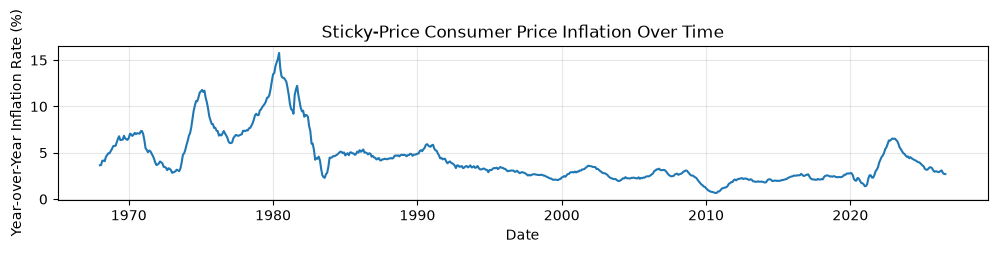

In [21]:
# lets view the whole dataset

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))

plt.plot(
    cpi_table["date"],
    cpi_table["value"]
)

plt.title("Sticky-Price Consumer Price Inflation Over Time")
plt.xlabel("Date")
plt.ylabel("Year-over-Year Inflation Rate (%)")
plt.grid(alpha=0.3)
plt.show()

In [25]:
target_ranges = {
    "1970s peak": ("1974-01-01", "1977-12-31"),
    "1980 peak":  ("1979-01-01", "1982-12-31"),
    "2020s peak": ("2022-01-01", "2024-12-31")
}


def find_peak_and_trough(df, start_date, end_date):
    # Find the highest value within the target range
    target = df[df["date"].between(start_date, end_date)]
    peak_index = target["value"].idxmax()

    increases = 0
    uptrend_start_index = None  # I define uptrend as three consecutive up months, this is from eye-balling the chart above

    # Search forward from the peak
    for i in range(peak_index + 1, len(df)):
        if df.loc[i, "value"] > df.loc[i - 1, "value"]:
            increases += 1
        else:
            increases = 0

        # Three consecutive monthly increases
        if increases == 3:
            uptrend_start_index = i - 3
            break

    # If no new uptrend was found, use the remaining dataset
    if uptrend_start_index is None:
        uptrend_start_index = len(df) - 1

    # Find the lowest value before the confirmed uptrend
    trough_index = df.loc[
        peak_index:uptrend_start_index, "value"
    ].idxmin()

    cycle = df.loc[peak_index:trough_index].copy()

    # Standardize the peak date as month zero
    peak_date = df.loc[peak_index, "date"]

    cycle["months_from_peak"] = (
        (cycle["date"].dt.year - peak_date.year) * 12
        + cycle["date"].dt.month
        - peak_date.month
    )

    return cycle, df.loc[peak_index], df.loc[trough_index]

1970s peak: Peak = 11.78% on 1975-02-01, Trough = 6.05% on 1977-01-01
1980 peak: Peak = 15.77% on 1980-06-01, Trough = 9.21% on 1981-06-01
2020s peak: Peak = 6.54% on 2022-12-01, Trough = 3.17% on 2025-05-01


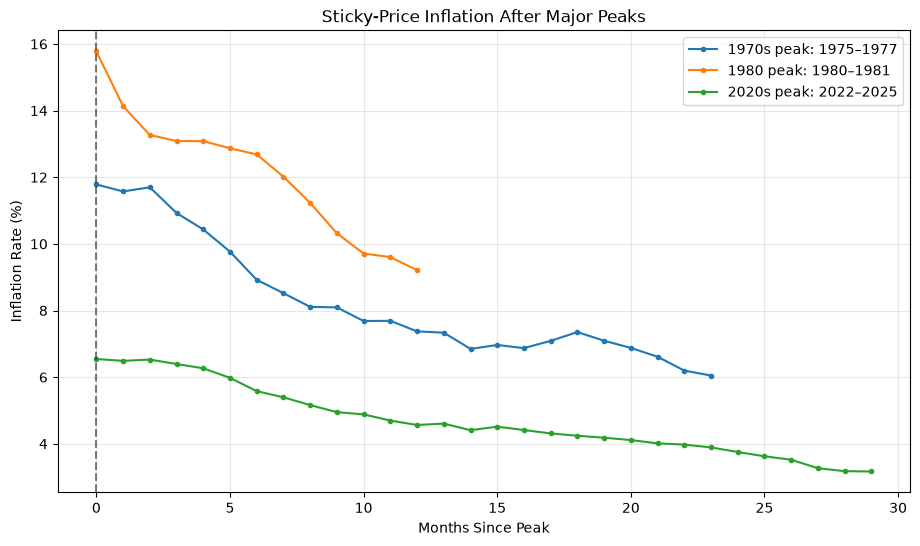

In [26]:
plt.figure(figsize=(11, 6))

for label, (start, end) in target_ranges.items():
    cycle, peak, trough = find_peak_and_trough(
        cpi_table, start, end
    )

    plt.plot(
        cycle["months_from_peak"],
        cycle["value"],
        marker="o",
        markersize=3,
        label=(
            f"{label}: "
            f"{peak['date'].year}–{trough['date'].year}"
        )
    )

    print(
        f"{label}: Peak = {peak['value']:.2f}% "
        f"on {peak['date'].date()}, "
        f"Trough = {trough['value']:.2f}% "
        f"on {trough['date'].date()}"
    )

plt.axvline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Sticky-Price Inflation After Major Peaks")
plt.xlabel("Months Since Peak")
plt.ylabel("Inflation Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

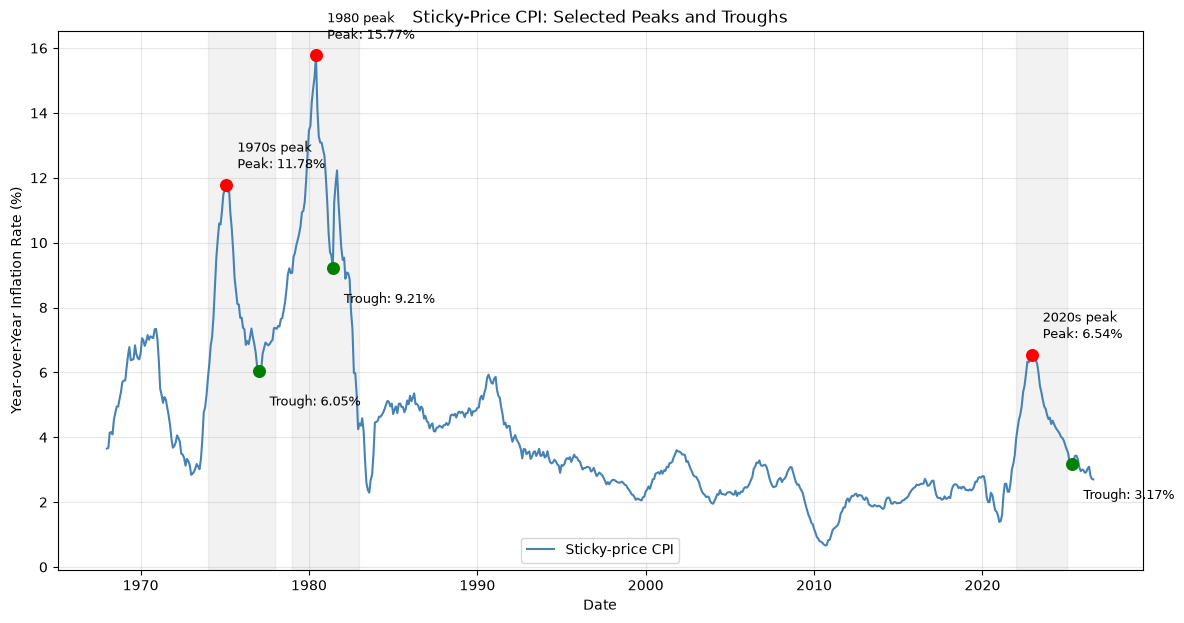

In [27]:
plt.figure(figsize=(14, 7))

# Plot the complete dataset
plt.plot(
    cpi_table["date"],
    cpi_table["value"],
    color="steelblue",
    linewidth=1.5,
    label="Sticky-price CPI"
)

for label, (start, end) in target_ranges.items():
    cycle, peak, trough = find_peak_and_trough(
        cpi_table, start, end
    )

    # Shade the range used to find each peak
    plt.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color="gray",
        alpha=0.1
    )

    # Mark peak
    plt.scatter(
        peak["date"],
        peak["value"],
        color="red",
        s=70,
        zorder=3
    )

    plt.annotate(
        f"{label}\nPeak: {peak['value']:.2f}%",
        xy=(peak["date"], peak["value"]),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=9
    )

    # Mark trough
    plt.scatter(
        trough["date"],
        trough["value"],
        color="green",
        s=70,
        zorder=3
    )

    plt.annotate(
        f"Trough: {trough['value']:.2f}%",
        xy=(trough["date"], trough["value"]),
        xytext=(8, -25),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Sticky-Price CPI: Selected Peaks and Troughs")
plt.xlabel("Date")
plt.ylabel("Year-over-Year Inflation Rate (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

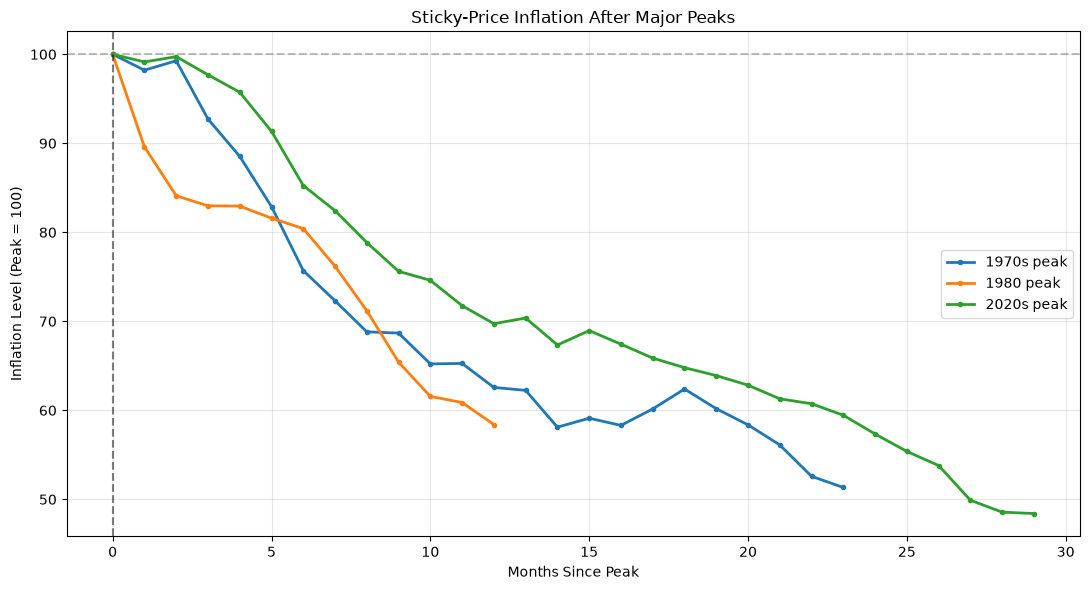

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare the data
cpi_table["date"] = pd.to_datetime(cpi_table["date"])
cpi_table["value"] = pd.to_numeric(
    cpi_table["value"],
    errors="coerce"
)

cpi_table = (
    cpi_table
    .dropna(subset=["date", "value"])
    .sort_values("date")
    .reset_index(drop=True)
)

# Date ranges used to locate each peak
target_ranges = {
    "1970s peak": ("1974-01-01", "1977-12-31"),
    "1980 peak":  ("1979-01-01", "1982-12-31"),
    "2020s peak": ("2022-01-01", "2024-12-31")
}


def find_peak_and_trough(df, start_date, end_date):
    # Find the peak inside the target range
    target = df[df["date"].between(start_date, end_date)]
    peak_index = target["value"].idxmax()

    consecutive_increases = 0
    uptrend_start_index = None

    # Look for three consecutive monthly increases
    for i in range(peak_index + 1, len(df)):
        if df.loc[i, "value"] > df.loc[i - 1, "value"]:
            consecutive_increases += 1
        else:
            consecutive_increases = 0

        if consecutive_increases == 3:
            uptrend_start_index = i - 3
            break

    # If no uptrend is found, use the rest of the dataset
    if uptrend_start_index is None:
        uptrend_start_index = len(df) - 1

    # Find the lowest point before the new uptrend
    trough_index = df.loc[
        peak_index:uptrend_start_index,
        "value"
    ].idxmin()

    cycle = df.loc[peak_index:trough_index].copy()

    peak = df.loc[peak_index]
    trough = df.loc[trough_index]

    # Make the peak month equal to zero
    cycle["months_from_peak"] = (
        (cycle["date"].dt.year - peak["date"].year) * 12
        + cycle["date"].dt.month
        - peak["date"].month
    )

    # Make the peak inflation level equal to 100
    cycle["standardized_value"] = (
        cycle["value"] / peak["value"]
    ) * 100

    return cycle, peak, trough


# Create the standardized chart
plt.figure(figsize=(11, 6))

for label, (start, end) in target_ranges.items():
    cycle, peak, trough = find_peak_and_trough(
        cpi_table,
        start,
        end
    )

    plt.plot(
        cycle["months_from_peak"],
        cycle["standardized_value"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=label
    )

plt.axvline(
    0,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    100,
    color="gray",
    linestyle="--",
    alpha=0.5
)

plt.title("Sticky-Price Inflation After Major Peaks")
plt.xlabel("Months Since Peak")
plt.ylabel("Inflation Level (Peak = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# from this chart you can tell that 2020 was the slowest one to cool off. 
# but its also the longest cool off periods, the other ones had a restart of inflation before 2020 cycle. 